# 01_project_setup
Cài đặt môi trường thí nghiệm, thiết lập hạt giống ngẫu nhiên để tái lập kết quả, xác định thiết bị tính toán thích hợp (GPU/MPS/CPU), và cấu hình các đường dẫn lưu trữ kết quả.


In [10]:
import sys
import shutil
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_DIR = Path('/Users/huynh/codes/kpdl/plan')
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.data import ProjectPaths, ensure_directories, load_metadata, get_num_classes, get_class_counts, build_data_loader
from src.models import get_simple_cnn
from src.train import train_model, evaluate_model
from src.utils import set_seed, get_device, get_pin_memory, get_num_workers, get_basic_transform, get_augmentation_transforms
from src.visualization import set_publication_style, plot_confusion_heatmap

SEED = 42
set_seed(SEED)
set_publication_style()

DEVICE = get_device()
print(f"Thiết bị sử dụng: {DEVICE}")

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_DIR = PATHS.results_dir('04_preprocessing_optimization')
REPORTS_DIR = PATHS.reports_dir('04_preprocessing_optimization')

ensure_directories(
    RESULTS_DIR,
    REPORTS_DIR,
    RESULTS_DIR / 'saved_models',
    RESULTS_DIR / 'confusion_matrices',
    RESULTS_DIR / 'training_histories',
)

USE_SUBSET = True
SUBSET_SIZE = 100
IMAGE_SIZE = 224
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)



Thiết bị sử dụng: mps


# 02_load_color_dataset
Nạp các tệp metadata (`train.csv`, `val.csv`, `test.csv`) và lọc chỉ sử dụng tập dữ liệu **COLOR** của PlantVillage.


In [11]:
train_df, val_df, test_df, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)

if USE_SUBSET:
    train_df = train_df.groupby('class_id').head(SUBSET_SIZE).reset_index(drop=True)
    val_df = val_df.groupby('class_id').head(max(10, SUBSET_SIZE // 5)).reset_index(drop=True)
    test_df = test_df.groupby('class_id').head(max(10, SUBSET_SIZE // 5)).reset_index(drop=True)
    print(f"[Cơ chế chạy nhanh] Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")
else:
    print(f"[Dữ liệu đầy đủ] Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

class_counts = get_class_counts(train_df)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Số lượng lớp học: {NUM_CLASSES}")
print(f"Lớp đông nhất: {class_counts.max()} mẫu | Lớp ít nhất: {class_counts.min()} mẫu")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")



[Cơ chế chạy nhanh] Train=3800 | Val=755 | Test=755
Số lượng lớp học: 38
Lớp đông nhất: 100 mẫu | Lớp ít nhất: 100 mẫu
Imbalance Ratio: 1.00


# 03_baseline_pipeline
Xây dựng PyTorch Dataset pipeline cho ảnh gốc (COLOR dataset) và thiết lập baseline transform bao gồm Resize(224, 224), chuyển sang Tensor, và chuẩn hóa với các giá trị mean/std của ImageNet.


In [12]:
baseline_transform = get_basic_transform(IMAGE_SIZE)
val_test_transform = baseline_transform

print('Dataset pipeline dùng chung: src.data.PlantDataset thông qua build_data_loader().')
print(f'Baseline transform: Resize({IMAGE_SIZE}, {IMAGE_SIZE}) + ToTensor + ImageNet normalization.')



Dataset pipeline dùng chung: src.data.PlantDataset thông qua build_data_loader().
Baseline transform: Resize(224, 224) + ToTensor + ImageNet normalization.


# 04_augmentation_experiments
Thiết lập các transformation pipeline tăng cường dữ liệu riêng biệt để chạy các thí nghiệm so sánh độc lập: baseline (không tăng cường), lật ngang (flip), quay (rotation), lật + quay, làm nhiễu màu (color jitter), và xóa ngẫu nhiên (random erasing).


In [13]:
train_transforms = get_augmentation_transforms(IMAGE_SIZE)

print('Các cấu hình augmentation được quản lý tập trung trong src.utils.get_augmentation_transforms().')
print(list(train_transforms.keys()))



Các cấu hình augmentation được quản lý tập trung trong src.utils.get_augmentation_transforms().
['baseline', 'exp1_flip', 'exp2_rotation', 'exp3_flip_rot', 'exp4_jitter', 'exp5_erasing']


# 05_training_pipeline
Phase 04 sử dụng **SimpleCNN** để đánh giá riêng tác động của preprocessing và augmentation. Mục tiêu là giữ mô hình cố định, chỉ thay đổi transform dữ liệu để xem kỹ thuật augmentation nào hữu ích nhất.

In [14]:
print('Model/training/evaluation dùng chung:')
print('- src.models.get_simple_cnn')
print('- src.train.train_model')
print('- src.train.evaluate_model')
print('Phase 04 không dùng MobileNetV2/pretrained model.')


Model/training/evaluation dùng chung:
- src.models.get_simple_cnn
- src.train.train_model
- src.train.evaluate_model
Phase 04 không dùng MobileNetV2/pretrained model.


# 06_experiment_tracking
Định cấu hình siêu tham số chung và chạy từng cấu hình augmentation bằng cùng một SimpleCNN. Phase này không xử lý imbalance bằng sampler/loss; các kỹ thuật đó được nghiên cứu riêng ở Phase 05 và Phase 06.

In [15]:
EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-3
PATIENCE = 3

experiments_history = {}
experiments_results = {}


def run_experiment(exp_name, train_transform, epochs=EPOCHS):
    print("\n" + "=" * 60)
    print(f"BẮT ĐẦU THỰC NGHIỆM: {exp_name.upper()}")
    print("=" * 60 + "\n")

    train_loader = build_data_loader(
        train_df, BASE_DIR, 'color', train_transform,
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(
        val_df, BASE_DIR, 'color', val_test_transform,
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = build_data_loader(
        test_df, BASE_DIR, 'color', val_test_transform,
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    model = get_simple_cnn(num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    save_path = RESULTS_DIR / 'saved_models' / f"{exp_name}_best.pth"
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs,
        device=DEVICE,
        save_path=save_path,
        patience=PATIENCE,
        use_early_stopping=True,
    )

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    eval_res = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)

    experiments_history[exp_name] = history
    experiments_results[exp_name] = eval_res

    print(f"\n[KẾT QUẢ {exp_name.upper()}] Test Acc: {eval_res['accuracy']:.4f} | Test Macro F1: {eval_res['macro_f1']:.4f}")
    return eval_res


for exp_name, transform in train_transforms.items():
    run_experiment(exp_name, transform)

aug_exps = list(train_transforms.keys())
best_aug = max(aug_exps, key=lambda name: experiments_results[name]['macro_f1'])
best_transform = train_transforms[best_aug]
print(f"\n>>> Augmentation tốt nhất được chọn: {best_aug} (Macro F1 = {experiments_results[best_aug]['macro_f1']:.4f})")

shutil.copyfile(
    RESULTS_DIR / 'saved_models' / f"{best_aug}_best.pth",
    RESULTS_DIR / 'saved_models' / 'best_augmentation_best.pth',
)
with open(RESULTS_DIR / 'saved_models' / 'best_aug.txt', 'w', encoding='utf-8') as file:
    file.write(best_aug)
print('Đã lưu checkpoint và tên augmentation tốt nhất.')




BẮT ĐẦU THỰC NGHIỆM: BASELINE

Epoch 01/10 | Train Loss: 3.1416 | Val Loss: 2.5570 | Val Acc: 0.2662 | Val Macro F1: 0.2114
Epoch 02/10 | Train Loss: 2.3126 | Val Loss: 1.8590 | Val Acc: 0.4914 | Val Macro F1: 0.4513
Epoch 03/10 | Train Loss: 1.9329 | Val Loss: 1.6323 | Val Acc: 0.5179 | Val Macro F1: 0.4919
Epoch 04/10 | Train Loss: 1.6984 | Val Loss: 1.4517 | Val Acc: 0.5550 | Val Macro F1: 0.5131
Epoch 05/10 | Train Loss: 1.5305 | Val Loss: 1.2900 | Val Acc: 0.6225 | Val Macro F1: 0.6111
Epoch 06/10 | Train Loss: 1.4374 | Val Loss: 1.1779 | Val Acc: 0.6503 | Val Macro F1: 0.6312
Epoch 07/10 | Train Loss: 1.3511 | Val Loss: 1.1048 | Val Acc: 0.6583 | Val Macro F1: 0.6363
Epoch 08/10 | Train Loss: 1.2384 | Val Loss: 0.9761 | Val Acc: 0.6901 | Val Macro F1: 0.6716
Epoch 09/10 | Train Loss: 1.1663 | Val Loss: 1.0060 | Val Acc: 0.6662 | Val Macro F1: 0.6573
Epoch 10/10 | Train Loss: 1.1256 | Val Loss: 1.0804 | Val Acc: 0.6715 | Val Macro F1: 0.6598

[KẾT QUẢ BASELINE] Test Acc: 0.7139 |

# 07_pipeline_comparison
Tổng hợp kết quả các thực nghiệm augmentation vào một DataFrame so sánh để phục vụ phân tích khoa học.

In [16]:
summary_records = []
for name, res in experiments_results.items():
    summary_records.append({
        'Experiment': name,
        'Macro F1': res['macro_f1'],
        'Recall': res['recall'],
        'Accuracy': res['accuracy']
    })

comparison_df = pd.DataFrame(summary_records)
print("=== BẢNG SO SÁNH CÁC PHƯƠNG PHÁP DATA AUGMENTATION ===")
display(comparison_df)


=== BẢNG SO SÁNH CÁC PHƯƠNG PHÁP DATA AUGMENTATION ===


,Experiment,Macro F1,Recall,Accuracy
0,baseline,0.697261,0.713596,0.713907
1,exp1_flip,0.668466,0.690789,0.690066
2,exp2_rotation,0.666935,0.677632,0.678146
3,exp3_flip_rot,0.639421,0.661404,0.660927
4,exp4_jitter,0.585949,0.602632,0.603974
5,exp5_erasing,0.663485,0.678070,0.678146


# 08_export_results
Lưu bảng so sánh, lịch sử huấn luyện và các biểu đồ phân tích augmentation.

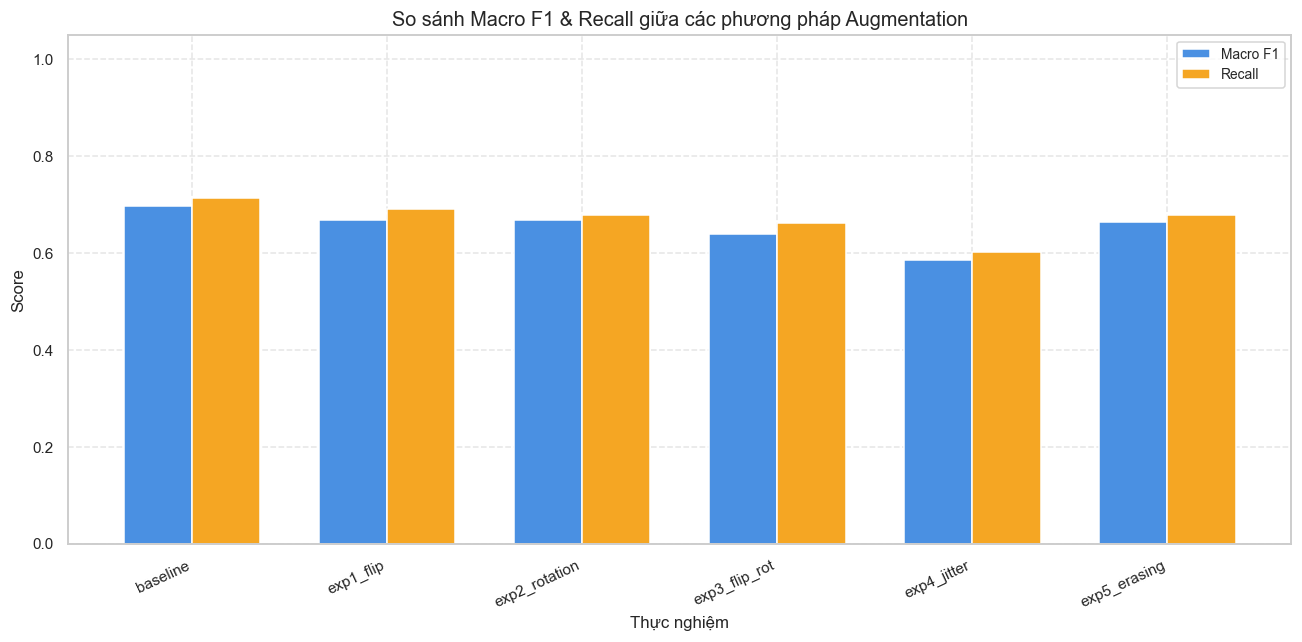

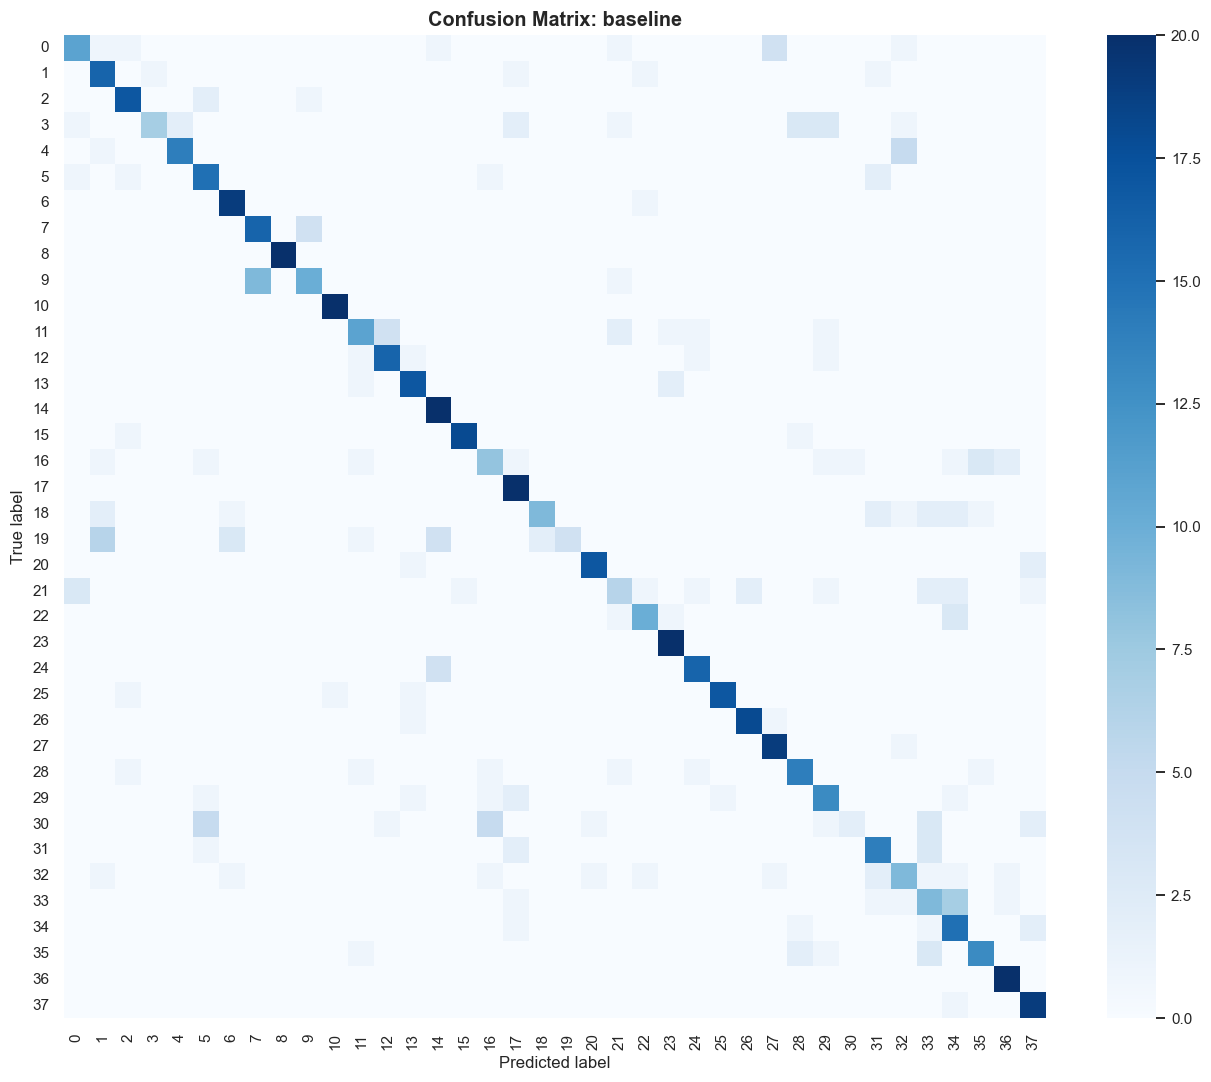

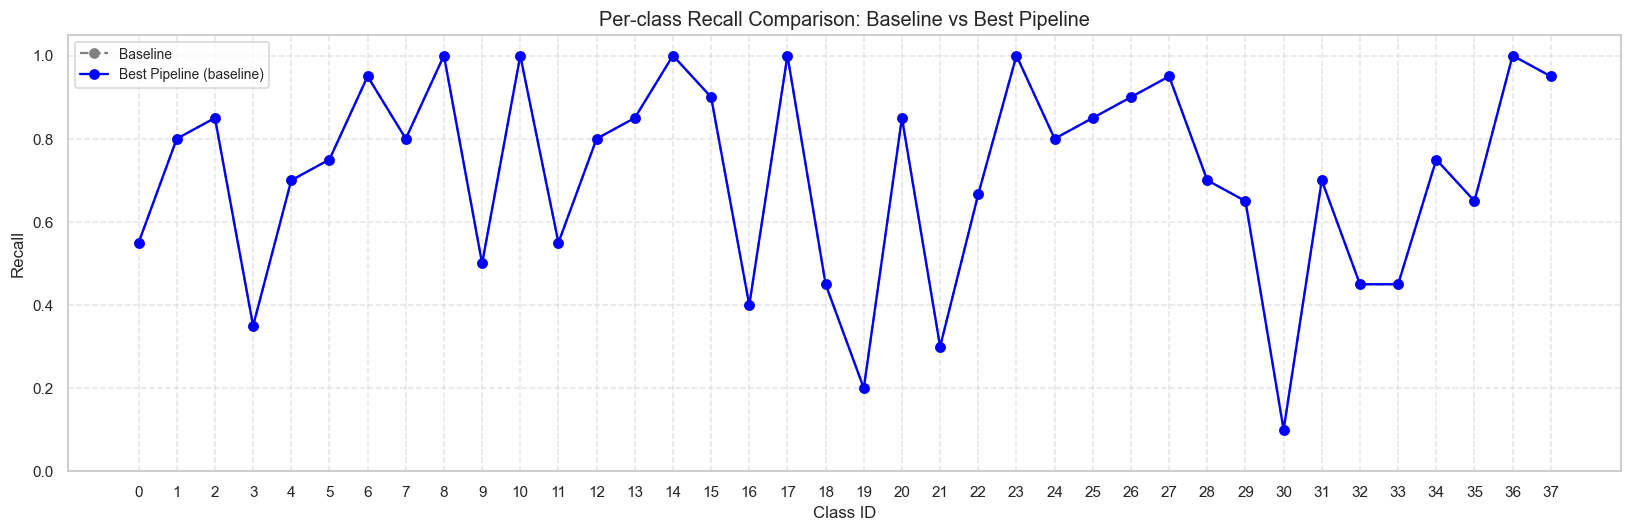

Đã lưu các kết quả và biểu đồ thành công!


In [17]:
# 1. Xuất so sánh tổng hợp thành CSV
comparison_df.to_csv(RESULTS_DIR / 'preprocessing_results.csv', index=False)

# 2. Lưu lịch sử huấn luyện
for name, hist in experiments_history.items():
    pd.DataFrame(hist).to_csv(RESULTS_DIR / 'training_histories' / f"{name}_history.csv", index=False)

# 3. Vẽ biểu đồ so sánh Macro F1 & Recall
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df['Macro F1'], width, label='Macro F1', color='#4A90E2')
plt.bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='#F5A623')
plt.xlabel('Thực nghiệm')
plt.ylabel('Score')
plt.title('So sánh Macro F1 & Recall giữa các phương pháp Augmentation')
plt.xticks(x, comparison_df['Experiment'], rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preprocessing_comparison_chart.png', dpi=300)
plt.show()

# 4. Vẽ Confusion Matrix cho best pipeline
best_pipeline = comparison_df.loc[comparison_df['Macro F1'].idxmax(), 'Experiment']
best_res = experiments_results[best_pipeline]
plot_confusion_heatmap(
    best_res['labels'],
    best_res['preds'],
    labels=list(range(NUM_CLASSES)),
    title=f'Confusion Matrix: {best_pipeline}',
    save_path=RESULTS_DIR / 'confusion_matrices' / f'{best_pipeline}_cm.png',
    figsize=(12, 10),
)

# 5. So sánh Per-class Recall: Baseline vs Best Pipeline
baseline_recalls = experiments_results['baseline']['per_class_recall']
best_recalls = best_res['per_class_recall']
plt.figure(figsize=(15, 5))
plt.plot(range(NUM_CLASSES), baseline_recalls, 'o--', color='gray', label='Baseline')
plt.plot(range(NUM_CLASSES), best_recalls, 'o-', color='blue', label=f'Best Pipeline ({best_pipeline})')
plt.title('Per-class Recall Comparison: Baseline vs Best Pipeline')
plt.xlabel('Class ID')
plt.ylabel('Recall')
plt.xticks(range(NUM_CLASSES))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_recall_comparison.png', dpi=300)
plt.show()
print("Đã lưu các kết quả và biểu đồ thành công!")



# 09_final_preprocessing_analysis
Phân tích kết quả thực nghiệm và tạo báo cáo tóm tắt cho Phase 04.

In [18]:
best_overall_row = comparison_df.loc[comparison_df['Macro F1'].idxmax()]
f1_baseline = comparison_df.loc[comparison_df['Experiment'] == 'baseline', 'Macro F1'].values[0]
f1_best_overall = best_overall_row['Macro F1']

summary_str = f"""=== BÁO CÁO PHASE 04: SIMPLECNN PREPROCESSING & AUGMENTATION STUDY ===
Ngày thực nghiệm: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. Cấu hình augmentation tối ưu nhất trên SimpleCNN:
   - Cấu hình: {best_overall_row['Experiment']}
   - Test Macro F1: {f1_best_overall:.4f} (Tăng {f1_best_overall - f1_baseline:+.4f} so với Baseline)
   - Test Recall: {best_overall_row['Recall']:.4f}
   - Test Accuracy: {best_overall_row['Accuracy']:.4f}

2. Đánh giá về Data Augmentation hiệu quả nhất:
   - Kỹ thuật tốt nhất: {best_overall_row['Experiment']} (Macro F1 = {f1_best_overall:.4f})
   - Nhận xét khoa học:
     * Random Rotation giúp mô hình nhận diện tốt hơn các cấu trúc đốm lá bị xoay tự nhiên do góc chụp.
     * Random Horizontal Flip tăng cường độ đối xứng hình học cho các lớp ít ảnh.
     * Color Jitter hỗ trợ mô hình chống chịu lại các dao động về độ sáng, độ bão hòa màu sắc của máy ảnh ngoài đồng ruộng.
     * Random Erasing hoạt động như một cơ chế regularization tốt, kích thích mô hình tập trung học nhiều vùng đốm lá nhỏ rải rác thay vì một vùng đốm lá lớn duy nhất.

3. Kết luận pipeline đề xuất cho Phase 05-07:
   - Model cố định: SimpleCNN.
   - Tiền xử lý: Resize(224, 224) + chuẩn hóa ImageNet.
   - Augmentation tốt nhất: {best_overall_row['Experiment']}.
   - Các kỹ thuật imbalance như WeightedRandomSampler và loss weighting được tách riêng sang Phase 05-06.
"""

# Lưu báo cáo vào REPORTS_DIR
with open(REPORTS_DIR / 'preprocessing_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_str)

print(summary_str)


=== BÁO CÁO PHASE 04: SIMPLECNN PREPROCESSING & AUGMENTATION STUDY ===
Ngày thực nghiệm: 2026-05-24 11:52:12

1. Cấu hình augmentation tối ưu nhất trên SimpleCNN:
   - Cấu hình: baseline
   - Test Macro F1: 0.6973 (Tăng +0.0000 so với Baseline)
   - Test Recall: 0.7136
   - Test Accuracy: 0.7139

2. Đánh giá về Data Augmentation hiệu quả nhất:
   - Kỹ thuật tốt nhất: baseline (Macro F1 = 0.6973)
   - Nhận xét khoa học:
     * Random Rotation giúp mô hình nhận diện tốt hơn các cấu trúc đốm lá bị xoay tự nhiên do góc chụp.
     * Random Horizontal Flip tăng cường độ đối xứng hình học cho các lớp ít ảnh.
     * Color Jitter hỗ trợ mô hình chống chịu lại các dao động về độ sáng, độ bão hòa màu sắc của máy ảnh ngoài đồng ruộng.
     * Random Erasing hoạt động như một cơ chế regularization tốt, kích thích mô hình tập trung học nhiều vùng đốm lá nhỏ rải rác thay vì một vùng đốm lá lớn duy nhất.

3. Kết luận pipeline đề xuất cho Phase 05-07:
   - Model cố định: SimpleCNN.
   - Tiền xử lý: Resi